# CBA 2026 SHAP Analysis: Global Landscape

Selected +CNV MOSA run: `20260505_131645`.

This notebook summarizes the CRISPR-Cas9 and drug-response SHAP outputs generated from the selected copy-number-augmented MOSA run. It focuses on publication-quality global figures: omic-layer rankings, global top features, target-level attribution composition, and copy-number-specific signals.

Figures are saved to `reports/cba2026/shap_analysis/20260505_131645/` as PNG, PDF, and SVG.


In [1]:
from pathlib import Path
import textwrap
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

TIMESTAMP = "20260505_131645"
TARGET_META = {
    "crisprcas9": "CRISPR-Cas9",
    "drugresponse": "Drug response",
}
OMIC_ORDER = [
    "transcriptomics",
    "methylation",
    "drugresponse",
    "crisprcas9",
    "conditionals",
    "copynumber",
]
OMIC_COLORS = {
    "transcriptomics": "#0072B2",
    "methylation": "#009E73",
    "drugresponse": "#D55E00",
    "crisprcas9": "#CC79A7",
    "conditionals": "#666666",
    "copynumber": "#E69F00",
}
TARGET_COLORS = {
    "CRISPR-Cas9": "#0072B2",
    "Drug response": "#D55E00",
}


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "reports" / "vae" / "files").exists() and (candidate / "docs").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing reports/vae/files and docs.")


ROOT = find_repo_root()
FILES_DIR = ROOT / "reports" / "vae" / "files"
COMPARE_DIR = ROOT / "reports" / "model_comparison_cnv_mosa_only" / "feature_augmentation" / TIMESTAMP
FIG_DIR = ROOT / "reports" / "cba2026" / "shap_analysis" / TIMESTAMP
FIG_DIR.mkdir(parents=True, exist_ok=True)


def set_nature_style():
    sns.set_theme(style="white", context="paper")
    mpl.rcParams.update({
        "figure.dpi": 180,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "font.family": "DejaVu Sans",
        "font.size": 7,
        "axes.titlesize": 8,
        "axes.labelsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 6,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    })


set_nature_style()


def shap_paths(target_family):
    return {
        "values": FILES_DIR / f"{TIMESTAMP}_shap_values_{target_family}_mean_abs.csv.gz",
        "feature_rank": FILES_DIR / f"{TIMESTAMP}_shap_feature_ranking_{target_family}_mean_abs.csv",
        "omic_rank": FILES_DIR / f"{TIMESTAMP}_shap_omic_ranking_{target_family}_mean_abs.csv",
        "top_features": FILES_DIR / f"{TIMESTAMP}_shap_values_top_features_{target_family}_mean_abs.feather",
    }


def require_files(paths):
    missing = [p for p in paths if not p.exists()]
    if missing:
        rel = "\n".join(str(p.relative_to(ROOT)) for p in missing)
        raise FileNotFoundError(f"Missing required input files:\n{rel}")


def clean_feature_name(feature, width=46):
    feature = str(feature)
    if "_" in feature:
        _, feature = feature.split("_", 1)
    feature = feature.replace("__", " / ").replace("_", " ")
    return textwrap.shorten(feature, width=width, placeholder="...")


def save_figure(fig, stem):
    paths = []
    for ext in ("png", "pdf", "svg"):
        path = FIG_DIR / f"{stem}.{ext}"
        fig.savefig(path)
        paths.append(path)
    return paths

print(f"ROOT: {ROOT}")
print(f"FIG_DIR: {FIG_DIR}")


ROOT: /mnt/scratch/scai/PhenPredCCMA
FIG_DIR: /mnt/scratch/scai/PhenPredCCMA/reports/cba2026/shap_analysis/20260505_131645


## Load SHAP Tables

The runner writes aggregate mean-absolute SHAP outputs with the `_mean_abs` suffix. The full value tables are wide by target; this notebook mostly uses the feature-ranking and top-200 feather outputs to keep plotting fast.


In [2]:
required = []
for target_family in TARGET_META:
    required.extend(shap_paths(target_family).values())
require_files(required)

feature_rank = {}
omic_rank = {}
top_features = {}
target_names = {}

for target_family, target_label in TARGET_META.items():
    paths = shap_paths(target_family)
    feature_rank[target_family] = (
        pd.read_csv(paths["feature_rank"])
        .assign(target_family=target_family, target_label=target_label)
    )
    omic_rank[target_family] = (
        pd.read_csv(paths["omic_rank"])
        .assign(target_family=target_family, target_label=target_label)
    )
    top_features[target_family] = (
        pd.read_feather(paths["top_features"])
        .assign(target_family=target_family, target_label=target_label)
    )
    target_names[target_family] = pd.read_csv(paths["values"], usecols=["target_name"])

summary = pd.DataFrame([
    {
        "target_family": target_family,
        "target_label": TARGET_META[target_family],
        "explained_targets": target_names[target_family]["target_name"].nunique(),
        "ranked_features": len(feature_rank[target_family]),
        "top_feature_rows": len(top_features[target_family]),
        "omic_layers": omic_rank[target_family]["omic_layer"].nunique(),
    }
    for target_family in TARGET_META
])

display(summary)
display(pd.concat(omic_rank.values(), ignore_index=True))


,target_family,target_label,explained_targets,ranked_features,top_feature_rows,omic_layers
0,crisprcas9,CRISPR-Cas9,500,12758,100000,5
1,drugresponse,Drug response,500,13257,100000,6


,omic_layer,importance,target_family,target_label
0,transcriptomics,0.000194,crisprcas9,CRISPR-Cas9
1,methylation,0.000161,crisprcas9,CRISPR-Cas9
2,drugresponse,0.000097,crisprcas9,CRISPR-Cas9
3,conditionals,0.000059,crisprcas9,CRISPR-Cas9
4,copynumber,0.000030,crisprcas9,CRISPR-Cas9
5,drugresponse,0.000544,drugresponse,Drug response
6,transcriptomics,0.000286,drugresponse,Drug response
7,methylation,0.000225,drugresponse,Drug response
8,crisprcas9,0.000078,drugresponse,Drug response
9,conditionals,0.000064,drugresponse,Drug response


## Figure 1: Global Omic Ranking

Mean absolute SHAP importance is averaged across all explained targets. The right panel reports the same information as a within-family share to make CRISPR-Cas9 and drug-response scales comparable.


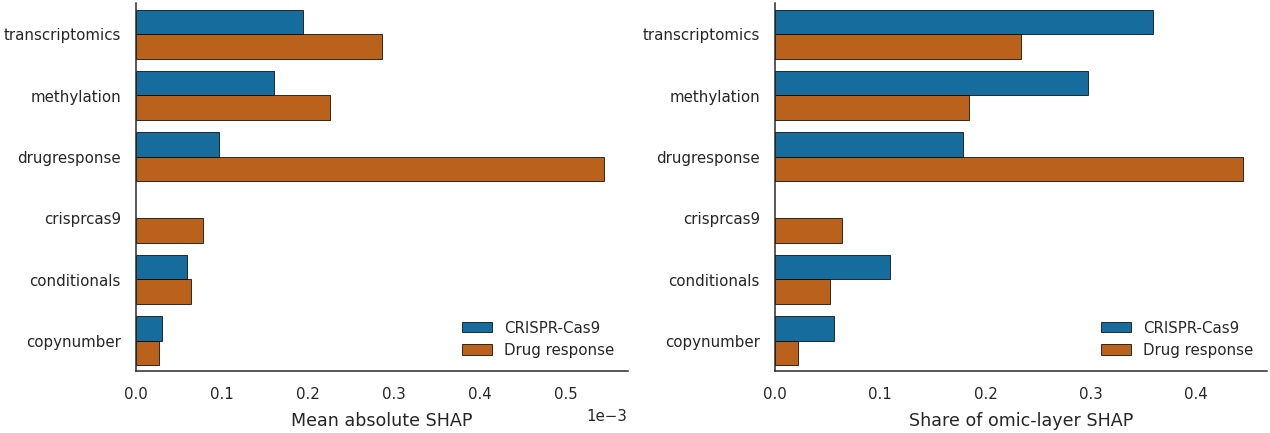

In [3]:
omic_all = pd.concat(omic_rank.values(), ignore_index=True)
omic_all["omic_layer"] = pd.Categorical(omic_all["omic_layer"], categories=OMIC_ORDER, ordered=True)
omic_all["importance_share"] = omic_all["importance"] / omic_all.groupby("target_family")["importance"].transform("sum")

fig, axes = plt.subplots(1, 2, figsize=(7.1, 2.45), constrained_layout=True)
for ax, value_col, xlabel in zip(
    axes,
    ["importance", "importance_share"],
    ["Mean absolute SHAP", "Share of omic-layer SHAP"],
):
    plot_df = omic_all.sort_values(["omic_layer", "target_label"])
    sns.barplot(
        data=plot_df,
        y="omic_layer",
        x=value_col,
        hue="target_label",
        order=[o for o in OMIC_ORDER if o in set(plot_df["omic_layer"].astype(str))],
        palette=TARGET_COLORS,
        ax=ax,
        edgecolor="black",
        linewidth=0.3,
    )
    ax.set_ylabel("")
    ax.set_xlabel(xlabel)
    ax.legend(title="", frameon=False, loc="lower right")
    if value_col == "importance":
        ax.ticklabel_format(axis="x", style="sci", scilimits=(-3, -3))

save_figure(fig, "fig1_global_omic_ranking")
plt.show()


## Figure 2: Global Top Features

These panels show the highest-ranked features after averaging SHAP importance across all targets in each family.


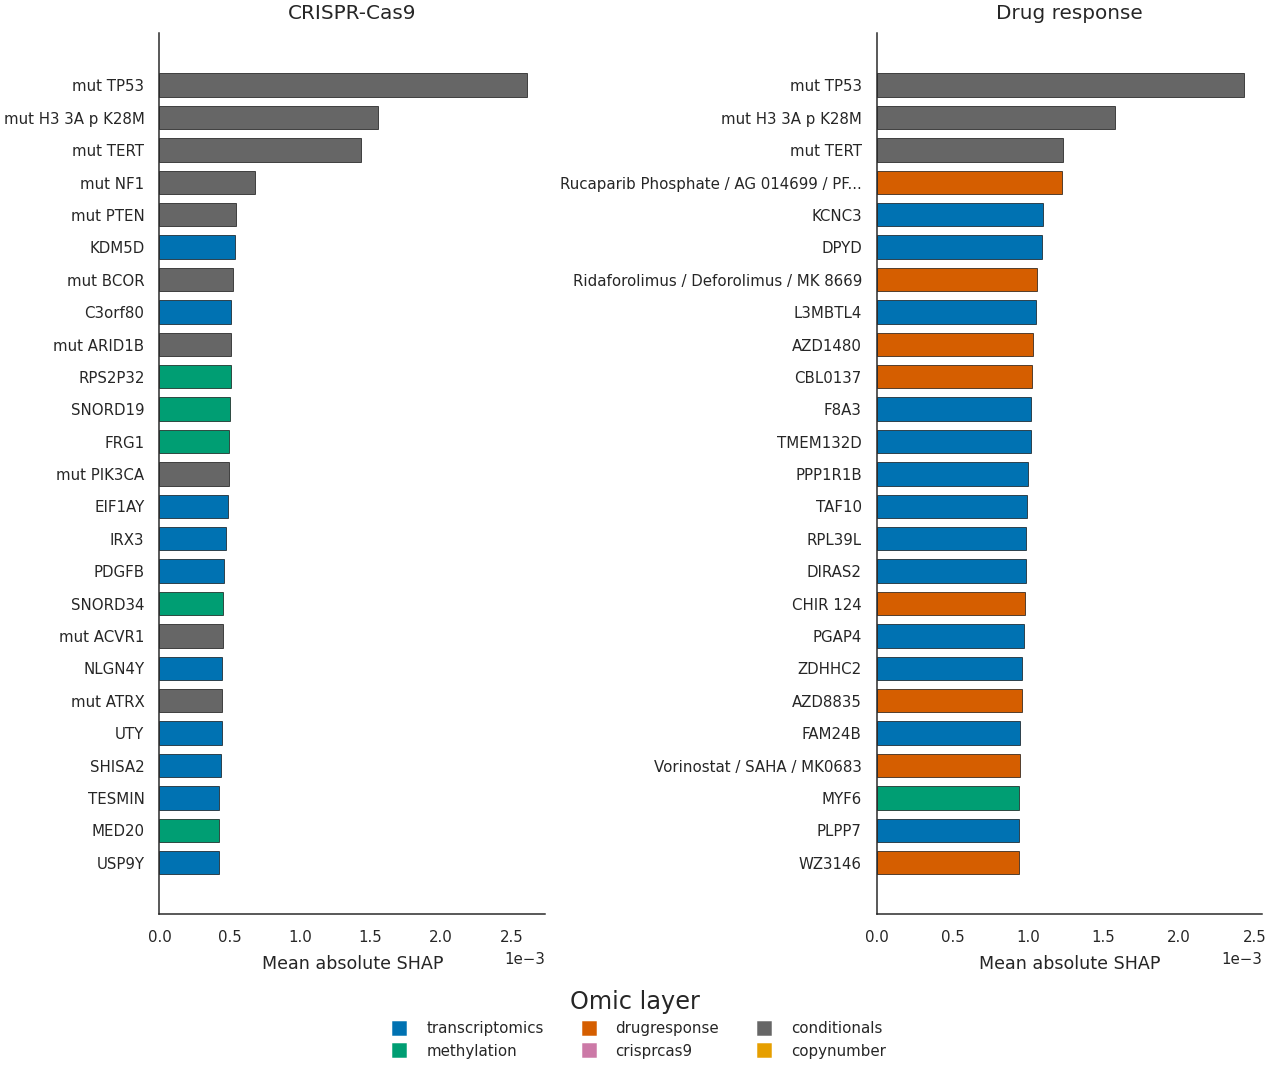

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(7.1, 6.0), constrained_layout=True)
for ax, (target_family, target_label) in zip(axes, TARGET_META.items()):
    d = feature_rank[target_family].head(25).copy()
    d = d.sort_values("importance", ascending=True)
    y = np.arange(len(d))
    colors = [OMIC_COLORS.get(layer, "#999999") for layer in d["omic_layer"]]
    ax.barh(y, d["importance"], color=colors, edgecolor="black", linewidth=0.25, height=0.72)
    ax.set_yticks(y)
    ax.set_yticklabels([clean_feature_name(v, width=42) for v in d["feature"]])
    ax.set_title(target_label)
    ax.set_xlabel("Mean absolute SHAP")
    ax.ticklabel_format(axis="x", style="sci", scilimits=(-3, -3))

handles = [plt.Line2D([0], [0], marker="s", linestyle="", color=c, label=k) for k, c in OMIC_COLORS.items()]
fig.legend(handles=handles, title="Omic layer", frameon=False, loc="outside lower center", ncol=3)
save_figure(fig, "fig2_global_top_features")
plt.show()


## Figure 3: Shared Global Feature Heatmap

The heatmap uses the union of the top-ranked features from both target families and shows where each feature is globally important.


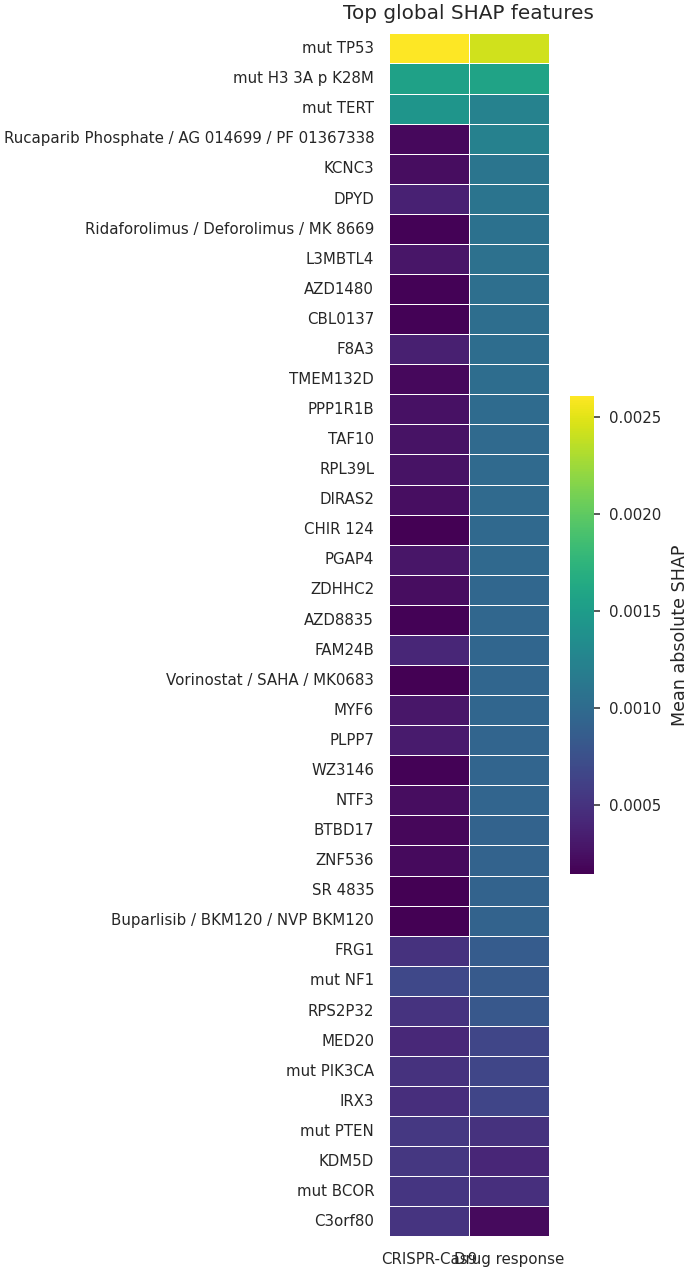

In [5]:
rank_all = pd.concat(feature_rank.values(), ignore_index=True)
feature_union = (
    rank_all.sort_values("importance", ascending=False)
    .groupby("target_family")
    .head(30)["feature"]
    .drop_duplicates()
)
wide = rank_all[rank_all["feature"].isin(feature_union)].pivot_table(
    index=["feature", "omic_layer"],
    columns="target_label",
    values="importance",
    aggfunc="first",
    fill_value=0,
)
wide["max_importance"] = wide.max(axis=1)
wide = wide.sort_values("max_importance", ascending=False).head(40).drop(columns="max_importance")
plot_mat = wide.copy()
plot_mat.index = [clean_feature_name(idx[0], width=48) for idx in plot_mat.index]

fig, ax = plt.subplots(figsize=(3.9, 7.1), constrained_layout=True)
sns.heatmap(
    plot_mat,
    cmap="viridis",
    linewidths=0.25,
    linecolor="white",
    cbar_kws={"label": "Mean absolute SHAP"},
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Top global SHAP features")
save_figure(fig, "fig3_global_feature_heatmap")
plt.show()


## Figure 4: Target-Level Omic Composition

For each explained target, SHAP contribution is summarized within the exported top-200 features. Shares are therefore top-200 composition shares, not whole-model SHAP mass.


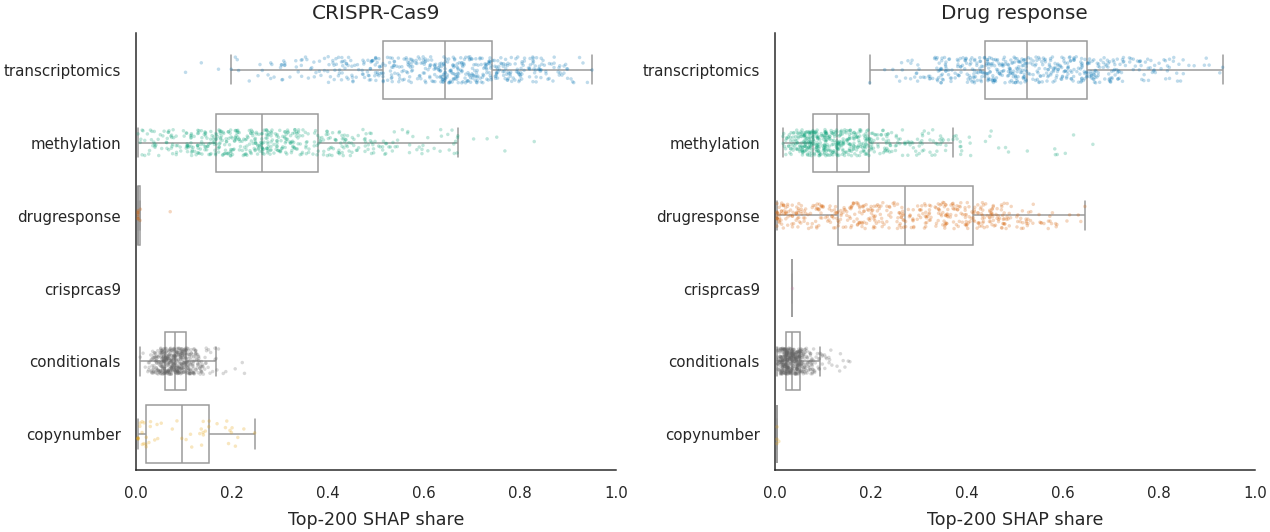

In [6]:
top_all = pd.concat(top_features.values(), ignore_index=True)
target_omic = (
    top_all.groupby(["target_family", "target_label", "target_name", "omic_layer"], as_index=False)["mean_abs_shap"]
    .sum()
)
target_total = target_omic.groupby(["target_family", "target_name"])["mean_abs_shap"].transform("sum")
target_omic["share_top200"] = target_omic["mean_abs_shap"] / target_total
omic_order_present = [o for o in OMIC_ORDER if o in set(target_omic["omic_layer"])]

fig, axes = plt.subplots(1, 2, figsize=(7.1, 3.0), sharex=True, constrained_layout=True)
for ax, (target_family, target_label) in zip(axes, TARGET_META.items()):
    d = target_omic[target_omic["target_family"] == target_family].copy()
    sns.boxplot(
        data=d,
        y="omic_layer",
        x="share_top200",
        order=omic_order_present,
        color="white",
        linewidth=0.6,
        fliersize=0,
        ax=ax,
    )
    sns.stripplot(
        data=d,
        y="omic_layer",
        x="share_top200",
        order=omic_order_present,
        hue="omic_layer",
        palette=OMIC_COLORS,
        size=1.4,
        alpha=0.25,
        jitter=0.18,
        ax=ax,
        legend=False,
    )
    ax.set_title(target_label)
    ax.set_xlabel("Top-200 SHAP share")
    ax.set_ylabel("")
    ax.set_xlim(0, 1)

save_figure(fig, "fig4_target_omic_composition_top200")
plt.show()


## Copy-Number Signal Tables

These tables make the +CNV contribution easy to inspect directly. They are also written to the figure/output directory.


In [7]:
cnv_global = (
    rank_all[rank_all["omic_layer"] == "copynumber"]
    .sort_values(["target_family", "importance"], ascending=[True, False])
    .groupby("target_family")
    .head(25)
    .reset_index(drop=True)
)
cnv_hits = (
    top_all[top_all["omic_layer"] == "copynumber"]
    .groupby(["target_family", "target_label", "omics_feature"], as_index=False)
    .agg(
        n_targets=("target_name", "nunique"),
        mean_importance=("mean_abs_shap", "mean"),
        max_importance=("mean_abs_shap", "max"),
    )
    .sort_values(["target_family", "n_targets", "mean_importance"], ascending=[True, False, False])
)
cnv_target_share = (
    target_omic[target_omic["omic_layer"] == "copynumber"]
    .sort_values(["target_family", "share_top200"], ascending=[True, False])
)

cnv_global.to_csv(FIG_DIR / "table_global_copynumber_feature_ranking.csv", index=False)
cnv_hits.to_csv(FIG_DIR / "table_copynumber_feature_frequency_top200.csv", index=False)
cnv_target_share.to_csv(FIG_DIR / "table_target_copynumber_share_top200.csv", index=False)

display(cnv_global.groupby("target_label").head(10))
display(cnv_hits.groupby("target_label").head(10))
display(cnv_target_share.groupby("target_label").head(10))


,feature,importance,omic_layer,target_family,target_label
0,copynumber_MED12,0.000248,copynumber,crisprcas9,CRISPR-Cas9
1,copynumber_IRAK1,0.000236,copynumber,crisprcas9,CRISPR-Cas9
2,copynumber_BCOR,0.000233,copynumber,crisprcas9,CRISPR-Cas9
3,copynumber_RBM10,0.000232,copynumber,crisprcas9,CRISPR-Cas9
4,copynumber_P2RY8,0.000229,copynumber,crisprcas9,CRISPR-Cas9
5,copynumber_WAS,0.000219,copynumber,crisprcas9,CRISPR-Cas9
6,copynumber_ZRSR2,0.000215,copynumber,crisprcas9,CRISPR-Cas9
7,copynumber_ATRX,0.000213,copynumber,crisprcas9,CRISPR-Cas9
8,copynumber_IRS4,0.000212,copynumber,crisprcas9,CRISPR-Cas9
9,copynumber_ATP2B3,0.000210,copynumber,crisprcas9,CRISPR-Cas9


,target_family,target_label,omics_feature,n_targets,mean_importance,max_importance
19,crisprcas9,CRISPR-Cas9,copynumber_MED12,45,0.000624,0.000980
14,crisprcas9,CRISPR-Cas9,copynumber_IRAK1,40,0.000601,0.000934
25,crisprcas9,CRISPR-Cas9,copynumber_RBM10,40,0.000583,0.000928
23,crisprcas9,CRISPR-Cas9,copynumber_P2RY8,39,0.000583,0.000888
5,crisprcas9,CRISPR-Cas9,copynumber_BCOR,38,0.000596,0.000900
36,crisprcas9,CRISPR-Cas9,copynumber_ZRSR2,33,0.000551,0.000835
33,crisprcas9,CRISPR-Cas9,copynumber_WAS,31,0.000579,0.000874
4,crisprcas9,CRISPR-Cas9,copynumber_ATRX,29,0.000568,0.000866
27,crisprcas9,CRISPR-Cas9,copynumber_RPS6KA3,28,0.000557,0.000822
3,crisprcas9,CRISPR-Cas9,copynumber_ATP2B3,28,0.000556,0.000828


,target_family,target_label,target_name,omic_layer,mean_abs_shap,share_top200
45,crisprcas9,CRISPR-Cas9,ANLN,copynumber,0.030391,0.247354
38,crisprcas9,CRISPR-Cas9,ANAPC5,copynumber,0.025409,0.224848
802,crisprcas9,CRISPR-Cas9,PFDN6,copynumber,0.021907,0.212307
818,crisprcas9,CRISPR-Cas9,PLRG1,copynumber,0.025778,0.207220
960,crisprcas9,CRISPR-Cas9,RACGAP1,copynumber,0.025676,0.200334
332,crisprcas9,CRISPR-Cas9,EFTUD2,copynumber,0.021900,0.198889
524,crisprcas9,CRISPR-Cas9,KCMF1,copynumber,0.025870,0.195894
598,crisprcas9,CRISPR-Cas9,MED14,copynumber,0.023773,0.192925
938,crisprcas9,CRISPR-Cas9,PSMD11,copynumber,0.026121,0.189295
697,crisprcas9,CRISPR-Cas9,NCL,copynumber,0.025494,0.186445


## Output Files


In [8]:
for path in sorted(FIG_DIR.glob("fig*")):
    print(path.relative_to(ROOT))
for path in sorted(FIG_DIR.glob("table_*")):
    print(path.relative_to(ROOT))


reports/cba2026/shap_analysis/20260505_131645/fig1_global_omic_ranking.pdf
reports/cba2026/shap_analysis/20260505_131645/fig1_global_omic_ranking.png
reports/cba2026/shap_analysis/20260505_131645/fig1_global_omic_ranking.svg
reports/cba2026/shap_analysis/20260505_131645/fig2_global_top_features.pdf
reports/cba2026/shap_analysis/20260505_131645/fig2_global_top_features.png
reports/cba2026/shap_analysis/20260505_131645/fig2_global_top_features.svg
reports/cba2026/shap_analysis/20260505_131645/fig3_global_feature_heatmap.pdf
reports/cba2026/shap_analysis/20260505_131645/fig3_global_feature_heatmap.png
reports/cba2026/shap_analysis/20260505_131645/fig3_global_feature_heatmap.svg
reports/cba2026/shap_analysis/20260505_131645/fig4_target_omic_composition_top200.pdf
reports/cba2026/shap_analysis/20260505_131645/fig4_target_omic_composition_top200.png
reports/cba2026/shap_analysis/20260505_131645/fig4_target_omic_composition_top200.svg
reports/cba2026/shap_analysis/20260505_131645/fig5_target_